# **Car Price Analysis**

### Dataset Introductions

Dataset content: For this project the data source Kaggle and there are just 205 cars.  The dataset tells us details about the car, from its size, engine specification, fuel, power, aspiration (turbo) efficiency and price. Limitations is we’re not told where in the US its sold, nor by who.  We can assume they’re all new cars without mileage and randomly sourced from various states around the US.   This potentially limits the reliability of the conclusions for example location bias due to climate or state wealth.

## Prepare

### Load



---

In [1]:
import pandas as pd
##This code loads the csv directly from data sets added to Kaggle.
##This is standard code taken from notebooks dynaimically loading data from kagglehub.
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "CarPrice_Assignment.csv"

# Load the latest version, use the file_path from the datasource.
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "hellbuoy/car-price-prediction",
  file_path,
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



## Clean
### Understanding the data
Explore, get familiar with the structure. Take steps to clean. Follow basic cleaning steps as planned. Read the Data Dictionary - carprices.xlsx workbook to understand the fields in the dataset.
## Cleaning checklist
- Data loss or data inconsistancy can be misleading if the scale of the data is small. 
- Error can change a result. As the set it small its worth doing.
- Duplicates. extra data copies of the same record.
- Formatting.  Column names cleanly named.

In [2]:
print("First 5 records:", df.head()) #first look at data.
#df.shape # Looking at the data there are 205 rows with 26 columns
#df.info() # Checking for size, nulls and types.  No issues.  No null values.  Move on.
data_cleaned = df.copy() #Copy the data so we don't overwrite it.
missing_data = data_cleaned.isnull().sum() # no null
#duplicate_count = data_cleaned.duplicated().sum()# No duplicate to sort out
#df.nunique() #skipped: There are no duplicates. Noted index provided so register of cars is consistent.
 #Observation 1: Looking at df["carname"] : The carname field isn't too useful. The model would be useful to user groupby if it was seperated cleanly.  Some data living in the name need checking against other fields.
 #Observation 2: some car make names are wrong.  Lets start cleaning up the dataset taking a copy just in case.

# No changes to make at this stage. 
# At least Convert all fields to lowercase to tidy up the fields before we dive deeper.
df.columns = df.columns.str.lower()
df.columns
# Now columns are tidy we can move on with the dataset.


First 5 records:    car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  p

Index(['car_id', 'symboling', 'carname', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

## Cleaning plan
Having looked at the data now I have outlined a plan to clean it.
- Relocate the 'make' and put it in a different column. Can be found before the first space. Checked by eye to make sure this is completely safe to use, then add them to 'make' field.
- Correct spelling of the makes which are in error.
- On some rows I checked, the carname mentions fuel or a feature which isn't correctly categorised. Code needs to verify this before changing or we could be writing over data we don't want to.
- Use AI to look for suggestion after giving it the list of car names if it can find more issues of hidden data in the name.
- Check for fields with very rare data we can merge.
- Fit data better: for example number of cylinder written as 'two' 'three' 'four' is less useful for filters than if it was 1,2,3,4. 
- Spot Outliers which may be data inaccuracies.

In [3]:
#df["carname"]
# Splits into a list per row, then extracts index 0 as a string for the car's Make to its own field.
df["make"] = df["carname"].str.split(' ').str[0]
df["make"]
# Displays an array of all distinct make values
print(df["make"].unique())
## wrong models. vw>volswagen

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan' 'nissan'
 'peugeot' 'plymouth' 'porsche' 'porcshce' 'renault' 'saab' 'subaru'
 'toyota' 'toyouta' 'vokswagen' 'volkswagen' 'vw' 'volvo']


In [4]:
# Create the dictionary of error I found of errors in spelling.
make_replacements = {
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'toyouta': 'toyota',
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'Nissan': 'nissan',          
    'alfa-romero': 'alfa-romeo'    
}

df['make'] = df['make'].replace(make_replacements)
#Standardising non-capitalisation in the whole set.
df['make'] = df['make'].str.lower()
df
#observer whole dataset to spot things in car name we still can use before we drop the column.
#(Auto)- reference to transmission which we don't have.      (diesel) - reference to fueltype which needs looking at to confirm.
#(turbo) - reference to aspiration which we need to confirm,
# Takes time. using AI to help find what wlse is hidden in carname. Copy and paste all column and carname field to gemini.

,car_id,symboling,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,make
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [5]:
# 1. Fix 'fueltype'
# Check if carname mentions 'diesel' and current fueltype is not already 'diesel'
diesel_mask = df['carname'].str.contains('diesel', case=False, na=False)
df.loc[diesel_mask & (df['fueltype'] != 'diesel'), 'fueltype'] = 'diesel'

# 2. Fix 'aspiration'
# Check if carname mentions 'turbo' and current aspiration is not already 'turbo'
turbo_mask = df['carname'].str.contains('turbo', case=False, na=False)
df.loc[turbo_mask & (df['aspiration'] != 'turbo'), 'aspiration'] = 'turbo'

# 3. Fix 'carbody'
# Mapping parenthetical wagon flags like '(sw)' to 'wagon' only if not already set
wagon_mask = df['carname'].str.contains(r'\(sw\)', case=False, na=False)
df.loc[wagon_mask & (df['carbody'] != 'wagon'), 'carbody'] = 'wagon'


##AI just suggested text like 'coupe' in carname.  Not sure. Would at this point check with data provider.
##I decied to rejected AI suggestions at this time.
### AI Suggested.
## Mapping coupe indicators like 'coupe' in carname
#coupe_mask = df['carname'].str.contains('coupe', case=False, na=False)
#df.loc[coupe_mask & (df['carbody'] != 'coupe'), 'carbody'] = 'coupe'
#After review Take a look at the row buick regal sport coupe (turbo). 
#Reason: In automotive terms, manufacturers often sold trim levels called "Sport Coupe" on 2-door
#  hardtops or hatchbacks, while the database schema might classify the official body style as a 
#  hatchback or hardtop. Forcing carbody to 'coupe' based solely on a marketing trim name in 
#  carname overwrites the original, more precise carbody classification.
#  Extract and create 'transmission' column (New Field)
##These change suggestion were skipped.
# 1. Deterministic Extraction (High Confidence)
# These are exact parenthetical patterns where we are 
# 100% sure what the text means:(sw) $\rightarrow$ carbody = 'wagon'(auto) $\rightarrow$ transmission = 'automatic'(turbo) $\rightarrow$ aspiration = 'turbo'(diesel) $\rightarrow$ fueltype = 'diesel'


In [6]:
#Cleaning checking for either invalid text options or rare options. 
# based fields where this might be found are given in this dataframe.
# using value_counts() function.
for field in df[["fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "enginetype"]]:
    print(df[field].value_counts(), end='\n|\n')

  

fueltype
gas       183
diesel     22
Name: count, dtype: int64
|
aspiration
std      167
turbo     38
Name: count, dtype: int64
|
doornumber
four    115
two      90
Name: count, dtype: int64
|
carbody
sedan          91
hatchback      68
wagon          32
hardtop         8
convertible     6
Name: count, dtype: int64
|
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
|
enginelocation
front    202
rear       3
Name: count, dtype: int64
|
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64
|


Some results are rare but all valid entries. Rare types can be grouped together as 'rare' to reduce noise.   We may consult an engineer on enginetype for example : a DOHCV is not a real acronym, but what should it be?  Noted as unresolve instead of changing it to Rare for now.

In [7]:
for col in df.columns.to_list():
  print(f"{col} \n{df[col].value_counts(normalize=True)} \n\n")

#nobody cares about the hardtop or the convertable because the frequency is rare, so rather than keep those name ratteling about we replace them.

car_id 
car_id
1      0.004878
2      0.004878
3      0.004878
4      0.004878
5      0.004878
         ...   
201    0.004878
202    0.004878
203    0.004878
204    0.004878
205    0.004878
Name: proportion, Length: 205, dtype: float64 


symboling 
symboling
 0    0.326829
 1    0.263415
 2    0.156098
 3    0.131707
-1    0.107317
-2    0.014634
Name: proportion, dtype: float64 


carname 
carname
peugeot 504                 0.029268
toyota corolla              0.029268
toyota corona               0.029268
subaru dl                   0.019512
mitsubishi outlander        0.014634
                              ...   
volkswagen super beetle     0.004878
volkswagen rabbit custom    0.004878
volvo 245                   0.004878
volvo diesel                0.004878
volvo 246                   0.004878
Name: proportion, Length: 147, dtype: float64 


fueltype 
fueltype
gas       0.892683
diesel    0.107317
Name: proportion, dtype: float64 


aspiration 
aspiration
std      0.814634
turbo 

In [8]:
##Tidy up the data use advanced feature engine.
##By using pipline transform the fuel type, turbo and number of doors automatically into new true or false column. 
##Later we make the option a feature in a chart instead of using text filtering we can use boolean.
from feature_engine.encoding import OneHotEncoder
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
      ('ohe', OneHotEncoder(variables=['fueltype', 'aspiration','doornumber','enginelocation']) )
])


df = pipeline.fit_transform(df)

# we can replace cylinders number as string with integers for better comparison.
# Define the translation rule from text to integer
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

# Map the string column to integers in a new 'cylinders' field
df['cylinders'] = df['cylindernumber'].map(cylinder_map)

#finally for things that are a bit rare and won't affect the data set by what they actually are we can just class as Rare
#this pipeline RareLabel does the heavy lifting for us.      Sourced from ML feature topic 3 of LMS.
from feature_engine.encoding import RareLabelEncoder

pipeline = Pipeline([
      ('rle_carbody', RareLabelEncoder(tol=0.1,
                                     n_categories=2,
                                     variables=['carbody']) ), 
      ('rle_fuelsystem', RareLabelEncoder(tol=0.08,
                                     n_categories=2,
                                     variables=['fuelsystem']) )
])

df = pipeline.fit_transform(df)

df = df.drop(columns=['carname', 'cylindernumber'])
df


,car_id,symboling,carbody,drivewheel,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,...,make,fueltype_gas,fueltype_diesel,aspiration_std,aspiration_turbo,doornumber_two,doornumber_four,enginelocation_front,enginelocation_rear,cylinders
0,1,3,Rare,rwd,88.6,168.8,64.1,48.8,2548,dohc,...,alfa-romeo,1,0,1,0,1,0,1,0,4
1,2,3,Rare,rwd,88.6,168.8,64.1,48.8,2548,dohc,...,alfa-romeo,1,0,1,0,1,0,1,0,4
2,3,1,hatchback,rwd,94.5,171.2,65.5,52.4,2823,ohcv,...,alfa-romeo,1,0,1,0,1,0,1,0,6
3,4,2,sedan,fwd,99.8,176.6,66.2,54.3,2337,ohc,...,audi,1,0,1,0,0,1,1,0,4
4,5,2,sedan,4wd,99.4,176.6,66.4,54.3,2824,ohc,...,audi,1,0,1,0,0,1,1,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,wagon,rwd,109.1,188.8,68.9,55.5,2952,ohc,...,volvo,1,0,1,0,0,1,1,0,4
201,202,-1,sedan,rwd,109.1,188.8,68.8,55.5,3049,ohc,...,volvo,1,0,0,1,0,1,1,0,4
202,203,-1,sedan,rwd,109.1,188.8,68.9,55.5,3012,ohcv,...,volvo,1,0,1,0,0,1,1,0,6
203,204,-1,sedan,rwd,109.1,188.8,68.9,55.5,3217,ohc,...,volvo,0,1,0,1,0,1,1,0,6


## Illustrating results.

Now the data is clean and formatter we can start looking at MatPlotLib charts to inspect it for quality.

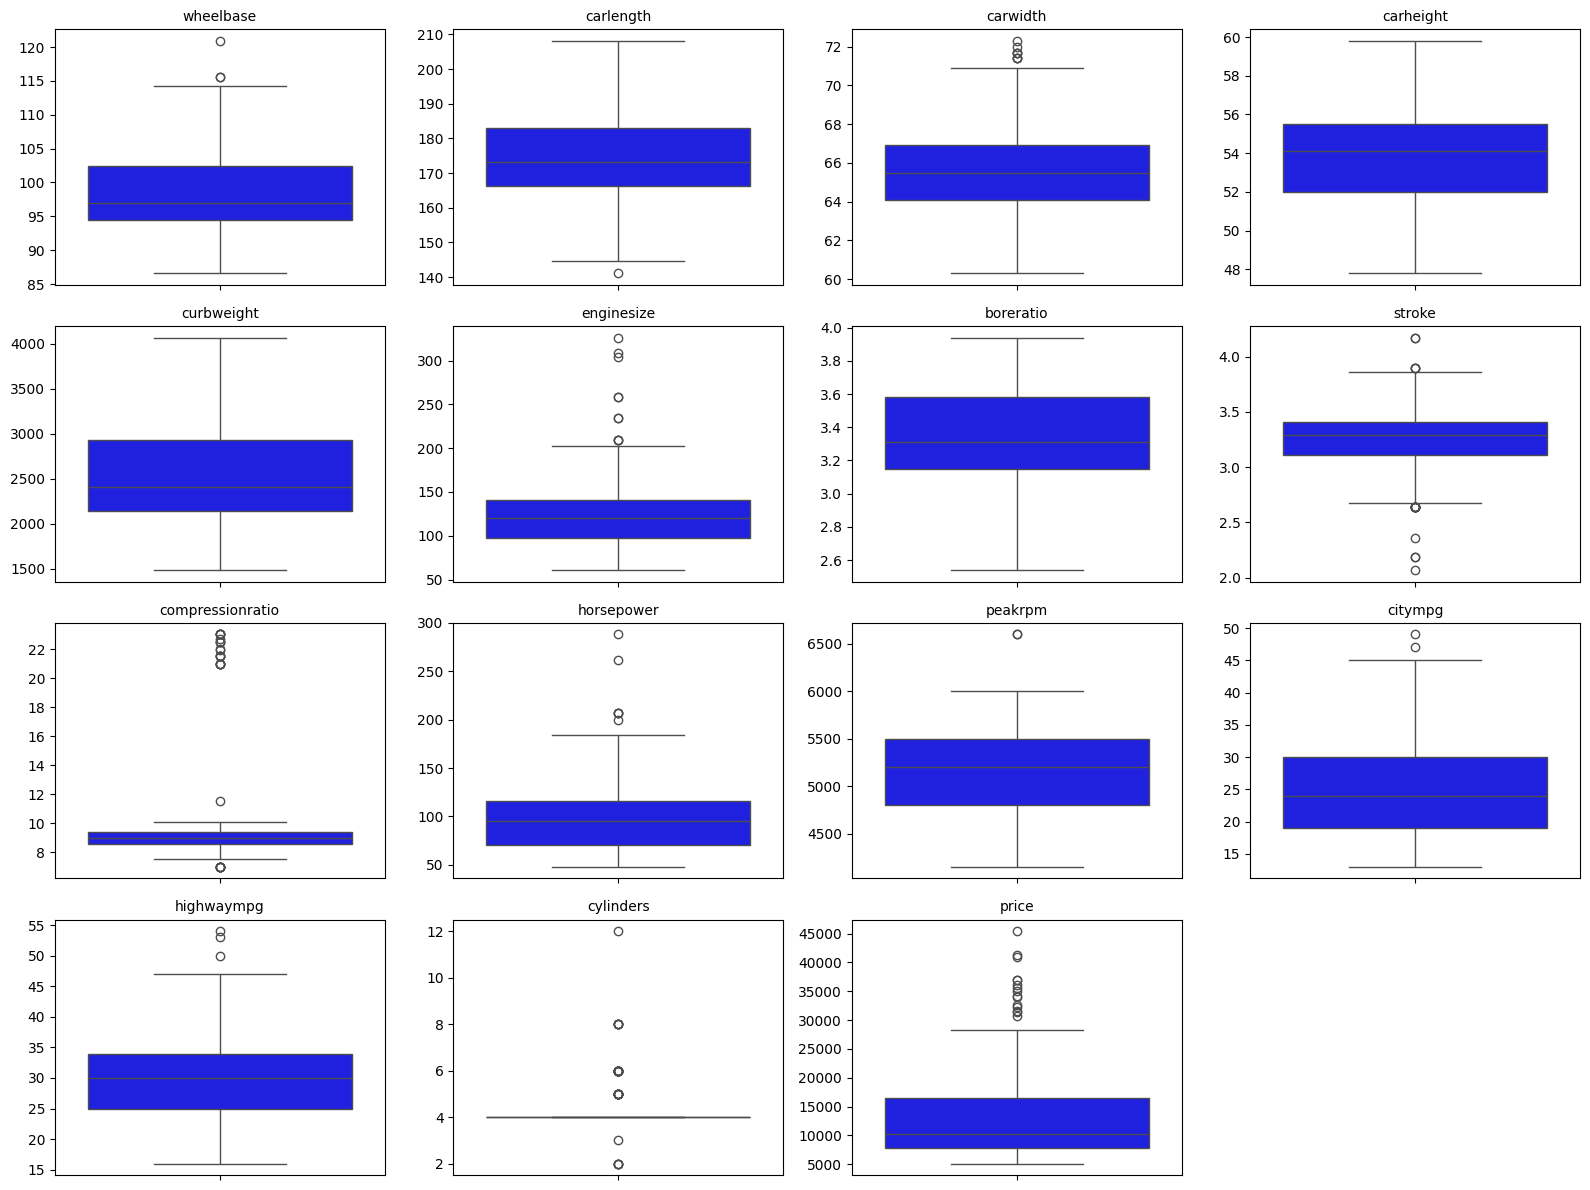

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of continuous columns to inspect numbers in the data.
num_cols = [
    'wheelbase', 'carlength', 'carwidth', 'carheight', 
    'curbweight', 'enginesize', 'boreratio', 'stroke', 
    'compressionratio', 'horsepower', 'peakrpm', 'citympg', 
    'highwaympg', 'cylinders', 'price'
]

# 2. Create a figure with a 4x4 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))

# 3. Flatten the 2D array of axes so we can loop through it easily
axes = axes.flatten()

# 4. Loop through each column and draw its boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='blue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

# 5. Hide any unused subplots (since 14 plots leave 2 empty slots in a 4x4 grid)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

# 6. Adjust layout so titles and labels do not overlap
plt.tight_layout()
plt.show()

The boxplots illustrate the spread of the data within the features. We need to spot Outliers. They can occur by chance in any distribution, but they can indicate novel behaviour or structures or extreme values which maybe wrong.  (wikipedia)
Have not identified any extreme data values with this set which may point to an error.

## Price and By Make

Regarding price my expectation is they driven by the Make of the car, so lets illustrate those before we get into specific features.

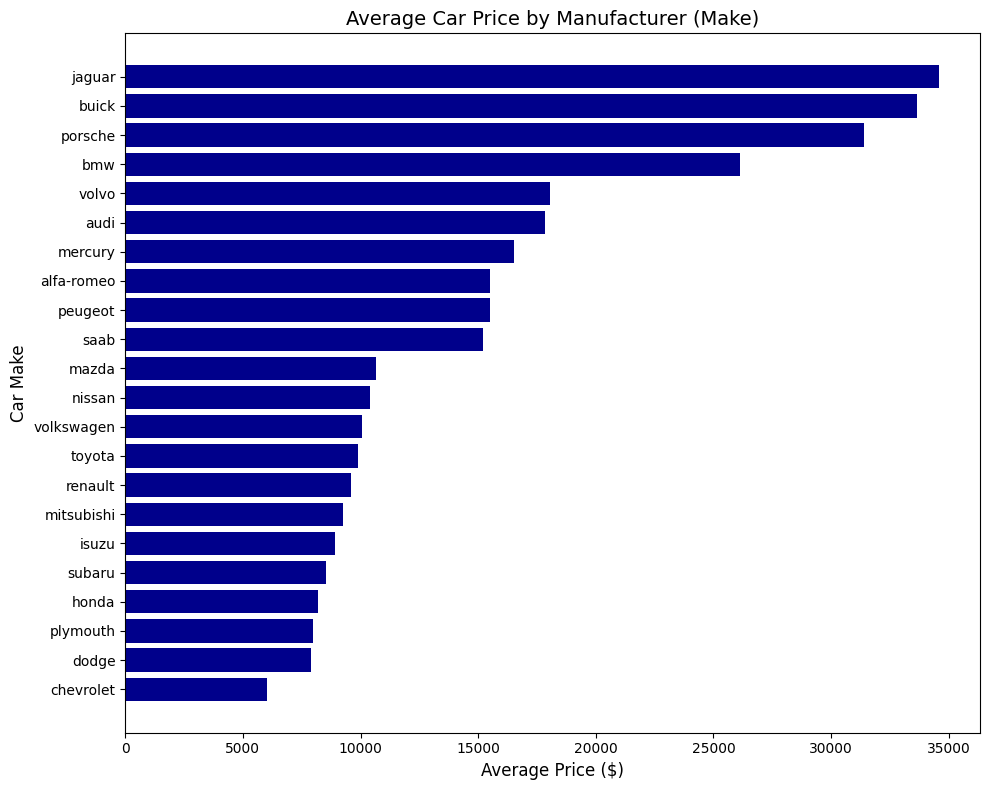

In [10]:
#Using again the Matplotlib library we can draw a simple bar graphic in order average of price in order
import matplotlib.pyplot as plt
# Group by 'make' and calculate average price for each make
avg_price_by_make = df.groupby('make')['price'].mean().sort_values(ascending=False)
# 1. Create a clean figure canvas
plt.figure(figsize=(10, 8))

# 2. Draw horizontal bar chart (sorted from highest to lowest price)
plt.barh(avg_price_by_make.index, avg_price_by_make.values, color='darkblue')

# 3. Add labels and title
plt.xlabel('Average Price ($)', fontsize=12)
plt.ylabel('Car Make', fontsize=12)
plt.title('Average Car Price by Manufacturer (Make)', fontsize=14)

# 4. Invert y-axis so the most expensive car make appears at the very top
plt.gca().invert_yaxis()

# 5. Render plot cleanly.
plt.tight_layout()
plt.show()

## Look at extreem prices first
 I had the idea it might be good to look at the factors in the top 20 % and bottom 20 % which we obviously present or lacking.
 then pick the most highly occuring as the factors brining the price up or down.
 In the top 20th and 80th percentile prices, what is special about those cars? That may contain more extreme examples of the factors we are looking for.

In [11]:
# 1. Dynamically calculate the 20th and 80th percentile prices
low_cutoff = df['price'].quantile(0.20)
high_cutoff = df['price'].quantile(0.80)

print(f"Bottom 20% threshold: ${low_cutoff:,.2f}")
print(f"Top 20% threshold: ${high_cutoff:,.2f}")

# 2. Build your boolean masks using the dynamic thresholds
low_price_mask = df['price'] < low_cutoff
high_price_mask = df['price'] > high_cutoff

Bottom 20% threshold: $7,385.80
Top 20% threshold: $17,493.80


Below $7,385.80 are Budget cars.  Above $17,493.80 are Luxury cars our main focus.
Using seaborn's sns.boxplot creator and a loop we can feed the chart names and labels directly into the loop.

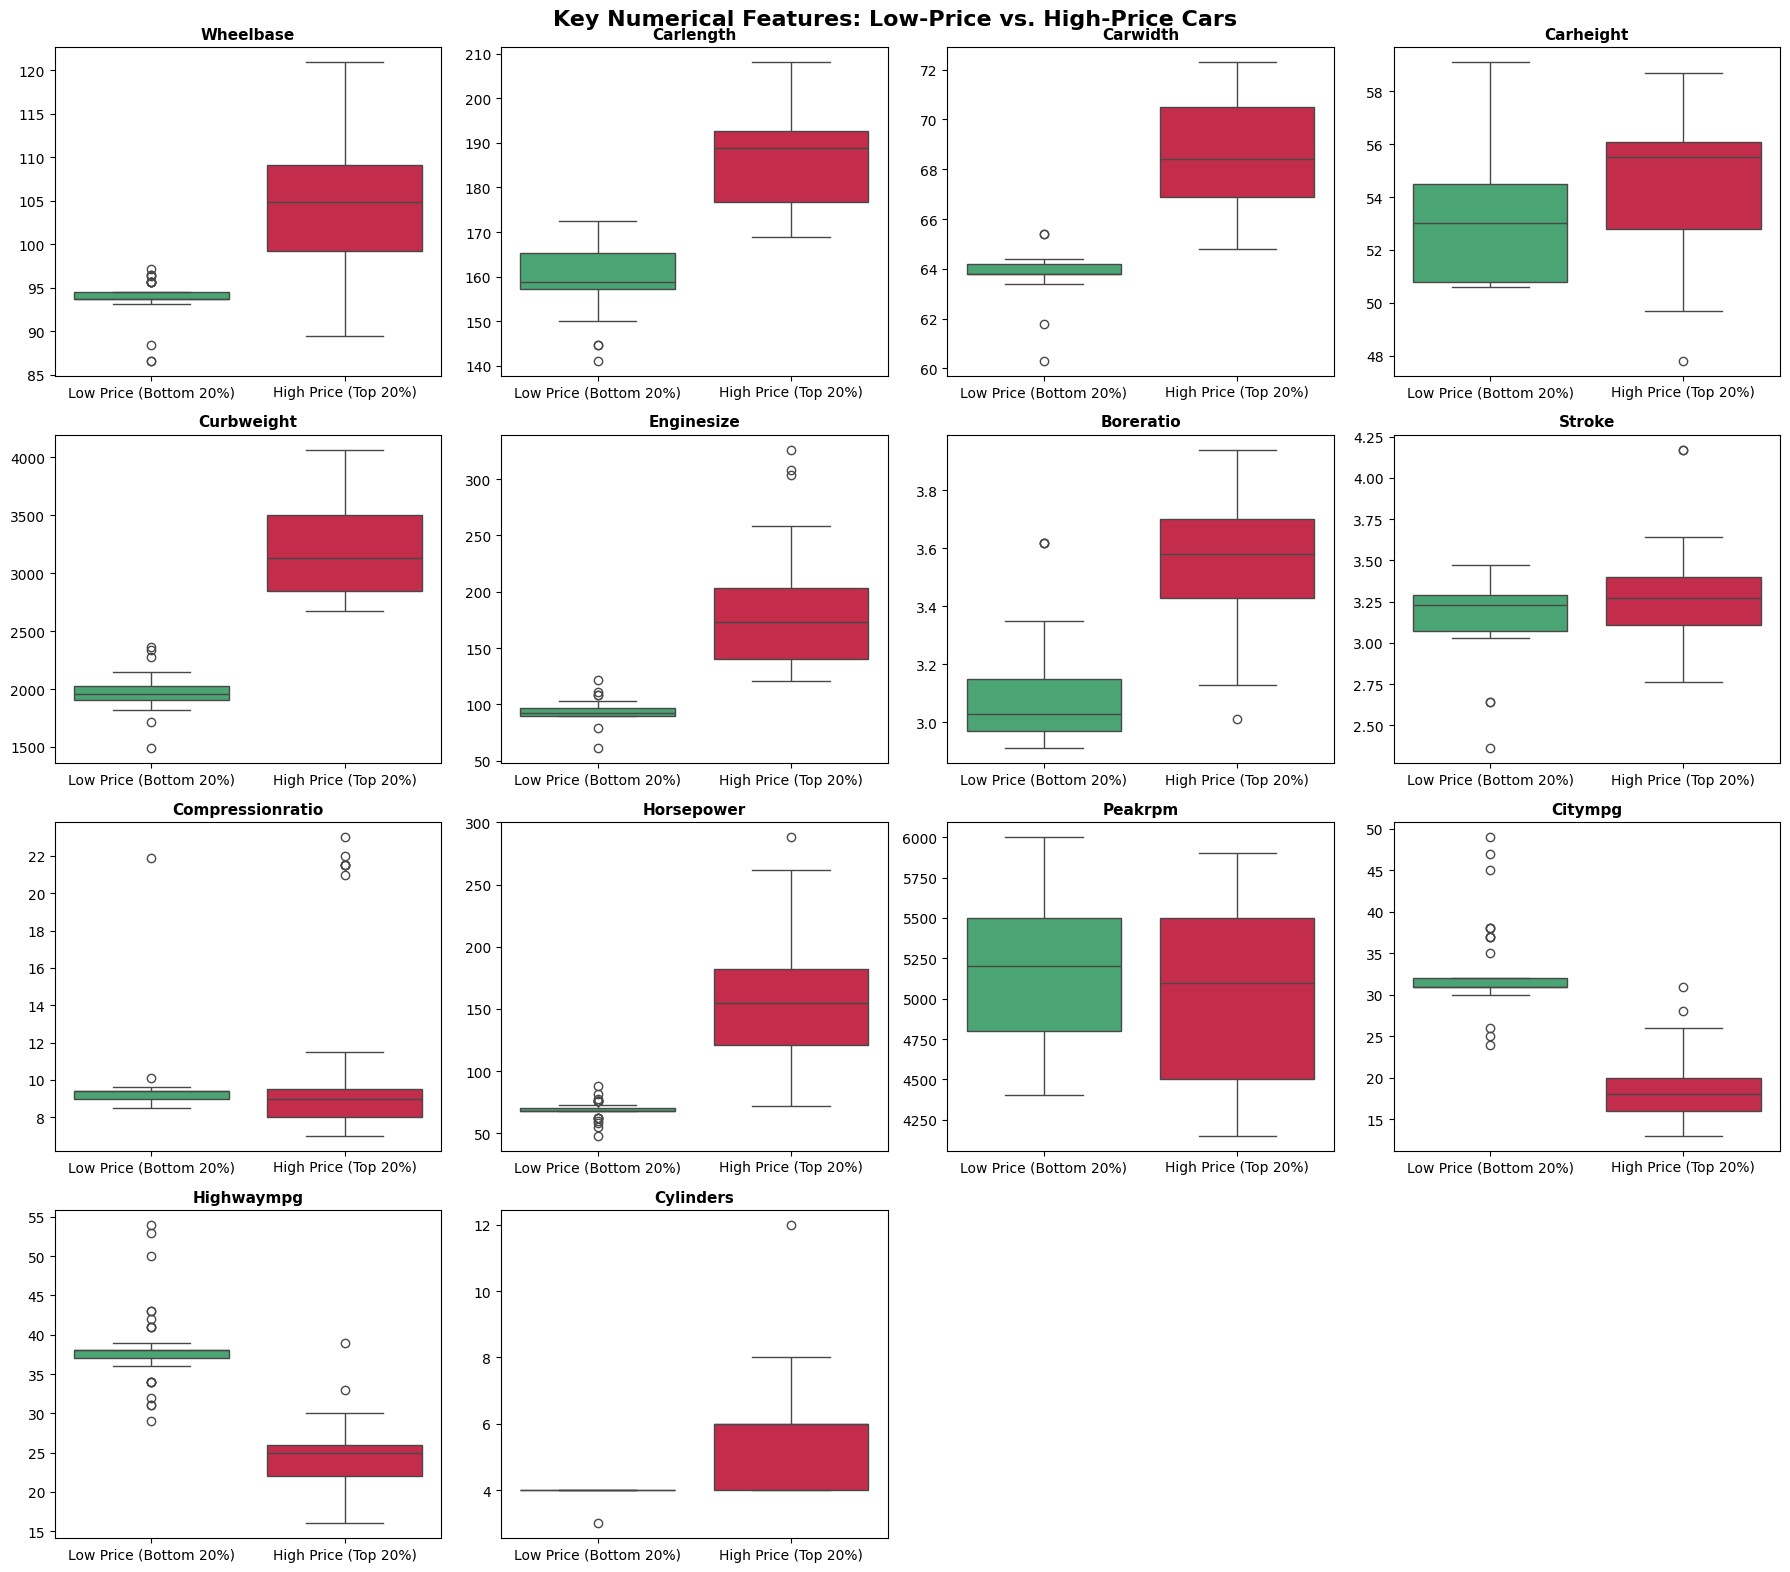

In [12]:
#Prepare a whole set of boxplots split by the two tiers of car sets by price.
# Add a label column to identify price tier.
df_low = df[df['price'] <= low_cutoff].copy()
df_low['price_group'] = 'Low Price (Bottom 20%)'

df_high = df[df['price'] >= high_cutoff].copy()
df_high['price_group'] = 'High Price (Top 20%)'

# Combine both sets into one DataFrame for plotting
df_quartiles = pd.concat([df_low, df_high])


# All possible numerical fields to compare
#num_fields = ['horsepower', 'enginesize', 'carwidth', 'curbweight', 'wheelbase', 'citympg']
continuous_fields = ['wheelbase', 'carlength', 'carwidth', 'carheight', ''
    'curbweight', 'enginesize', 'boreratio', 'stroke', 
    'compressionratio', 'horsepower', 'peakrpm', 'citympg', 
    'highwaympg', 'cylinders',]
              


# Set up a grid of 4 rows by 4 columns
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))
axes = axes.flatten()

palette_colors = {'Low Price (Bottom 20%)': 'mediumseagreen', 'High Price (Top 20%)': 'crimson'}

for i, field in enumerate(continuous_fields):
    sns.boxplot(
        data=df_quartiles,
        x='price_group',
        y=field,
        hue='price_group',
        palette=palette_colors,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(field.title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide unused subplots in the grid
for j in range(len(continuous_fields), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Key Numerical Features: Low-Price vs. High-Price Cars', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## High Priced cars have 
- a large range of larger wheelbases from 100 upwards.
- a longer length, wider, heavier and sometime taller car.
- a large range of larger engine size from 130 upwards.
- a larger stroke/bore ratio, much larger than any low price cars.
- a much larger range of horsepower, much larger than any low price cars.
- a much lower mpg rate in general.
- often have more than 4 cylinders.

In [13]:
# Filter high/low priced cars top 20.

high_price_mask = df['price'] > high_cutoff
low_price_mask = df['price'] < low_cutoff
# Select expected key performance columns alongside make and price
high_spec_comparison = df.loc[high_price_mask, ['make', 'enginesize', 'horsepower', 'cylinders', 'price',  'enginetype' ,'boreratio']]
low_spec_comparison = df.loc[low_price_mask, ['make', 'enginesize', 'horsepower', 'cylinders', 'price',  'enginetype', 'boreratio']]

# Sort by price descending to inspect the correlation
#print(high_spec_comparison .sort_values(by='price', ascending=False))
print(low_spec_comparison.sort_values(by='price', ascending=True))
#The inspected data looks okay. These are priced high because their engines are massive.
#high_spec_comparison.count()
 


           make  enginesize  horsepower  cylinders   price enginetype  \
138      subaru          97          69          4  5118.0       ohcf   
18    chevrolet          61          48          3  5151.0          l   
50        mazda          91          68          4  5195.0        ohc   
150      toyota          92          62          4  5348.0        ohc   
76   mitsubishi          92          68          4  5389.0        ohc   
32        honda          79          60          4  5399.0        ohc   
89       nissan          97          69          4  5499.0        ohc   
118    plymouth          90          68          4  5572.0        ohc   
21        dodge          90          68          4  5572.0        ohc   
51        mazda          91          68          4  6095.0        ohc   
77   mitsubishi          92          68          4  6189.0        ohc   
24        dodge          90          68          4  6229.0        ohc   
120    plymouth          90          68          4 

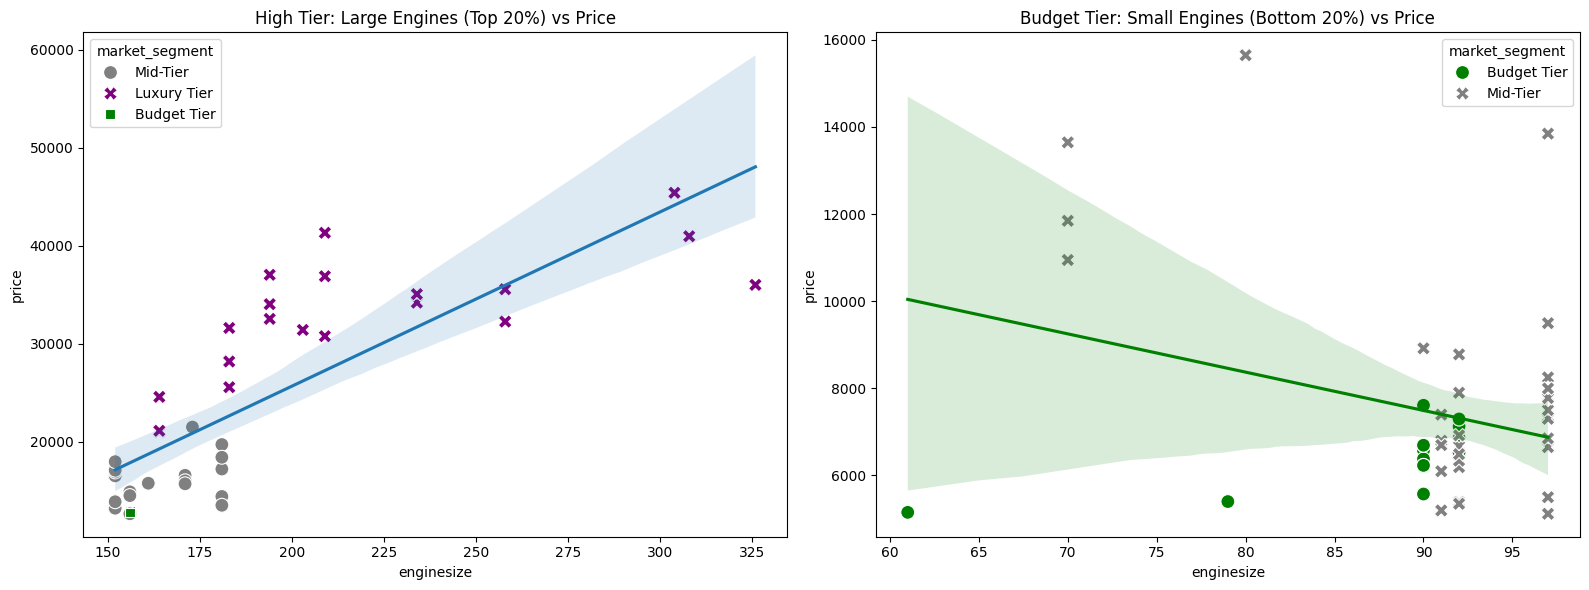

In [14]:
# 1. Prepare dynamic high/low flags and engine thresholds
high_engine_cutoff = df['enginesize'].quantile(0.80)
low_engine_cutoff = df['enginesize'].quantile(0.20)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define manufacturer brand lists well known top and low priced from chart.
luxury_makes = ['porsche', 'jaguar', 'bmw', 'buick']
budget_makes = ['honda', 'dodge', 'plymouth', 'chevrolet']

# 2. Create a clean category column based on brand lists
def assign_market_segment(make_name):
    if make_name in luxury_makes:
        return 'Luxury Tier'
    elif make_name in budget_makes:
        return 'Budget Tier'
    else:
        return 'Mid-Tier'

#Use the function above to assign the market segment we might see.
df['market_segment'] = df['make'].apply(assign_market_segment)

# 3. Calculate dynamic engine size thresholds using quantiles
high_engine_cutoff = df['enginesize'].quantile(0.80)
low_engine_cutoff = df['enginesize'].quantile(0.20)

# 4. Create canvas for 2 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------------------------
# CHART 1: High-Tier / Luxury Focus (Large Engines)
# ----------------------------------------------------
high_df = df[df['enginesize'] >= high_engine_cutoff].copy()

sns.scatterplot(
    data=high_df,
    x='enginesize',
    y='price',
    hue='market_segment',
    style='market_segment',
    palette={'Luxury Tier': 'purple', 'Mid-Tier': 'gray', 'Budget Tier': 'green'},
    s=100,
    ax=axes[0]
)
# Add regression line to show general trend direction
sns.regplot(data=high_df, x='enginesize', y='price', scatter=False, ax=axes[0])
axes[0].set_title('High Tier: Large Engines (Top 20%) vs Price', fontsize=12)

# ----------------------------------------------------
# CHART 2: Budget Focus (Small Engines)
# ----------------------------------------------------
low_df = df[df['enginesize'] <= low_engine_cutoff].copy()

sns.scatterplot(
    data=low_df,
    x='enginesize',
    y='price',
    hue='market_segment',
    style='market_segment',
    palette={'Luxury Tier': 'purple', 'Mid-Tier': 'gray', 'Budget Tier': 'green'},
    s=100,
    ax=axes[1]
)
sns.regplot(data=low_df, x='enginesize', y='price', scatter=False, ax=axes[1], color='green')
axes[1].set_title('Budget Tier: Small Engines (Bottom 20%) vs Price', fontsize=12)

plt.tight_layout()
plt.show()

If we use the corr function we will get an number for the correlations (relationships) between various car features and their sales price.

In [15]:
#List the top
price_scores = df.corr(numeric_only=True)['price']
positive_scores = price_scores[price_scores > 0].sort_values(ascending=False)
print(positive_scores)

price                  1.000000
enginesize             0.874145
curbweight             0.835305
horsepower             0.808139
carwidth               0.759325
cylinders              0.718305
carlength              0.682920
wheelbase              0.577816
boreratio              0.553173
enginelocation_rear    0.324973
aspiration_turbo       0.226694
fueltype_diesel        0.121592
carheight              0.119336
stroke                 0.079443
compressionratio       0.067984
doornumber_four        0.031835
Name: price, dtype: float64


This demonstrates there is some correlation with engine size which is obvious as engines cost a lot so would push up the price.
this alone proves nothing, we should be looking at a number of factors together which are desirable without spending a lot on huge engines.

Instead we could think of big cars vs small cars with some kind of measure which takes into account the wheelbase, length, widith, height of the car.
To combine those factors.  We can drop  mpg because its not a desirable factor to include.

Looking at the high end of the cars in the set and with my knowledge of cars I'm going to focus straight away on the areas in those high priced cars that may contribute to their price.
Engine size, engine type, cylinders,  horsepower, carlength and boreratio

If R (positive) is the correlation is it a measure of how related the value is to price but its not the coefficient of determination (how much can be explained), for that you need to multiple R by itself R^2

We can plot the distrubution for those highly interesting features including the new volume measurement.
Using seaborn's sns.regplot plot and a loop we can feed the chart names and labels directly into the loop.

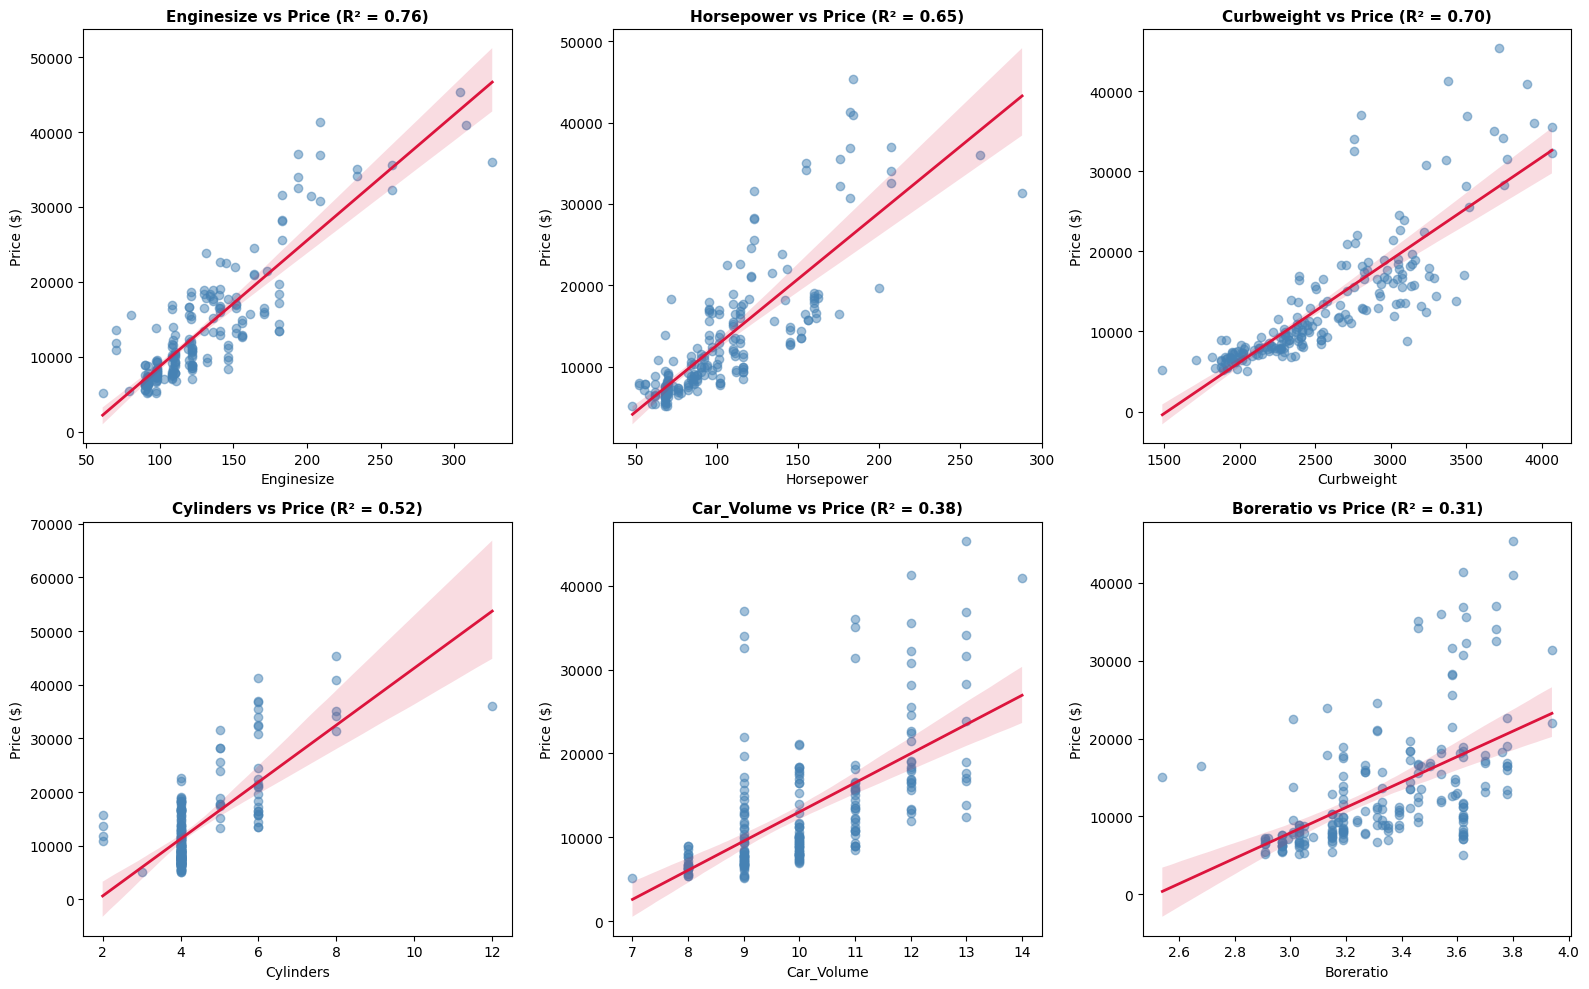

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# create a new measure to deal with length width and height as one value Volume in metric.
# Convert volume to cubic meters
df['car_volume'] = (df['carlength'] * df['carwidth'] * df['carheight'] * 0.000016387064).round().astype(int)


# 1. Define the 6 selected features identified as still having positive effect on price.
selected_features = [
    'enginesize', 'horsepower',  'curbweight',
    'cylinders', 'car_volume', 'boreratio'
]

# 2. Create a figure with a 2x3 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# 3. Flatten the 2D grid array into a single 1D list for easy looping
axes = axes.flatten()

# 4. Loop through each feature and create a scatter plot with a trendline
for i, feature in enumerate(selected_features):
    sns.regplot(
        data=df,
        x=feature,
        y='price',
        ax=axes[i],
        scatter_kws={'alpha': 0.5, 'color': 'steelblue'},  # Translucent points to handle overlap
        line_kws={'color': 'crimson', 'linewidth': 2}     # Red trendline highlighting direction
    )
    
    # Calculate R^2 score for title context
    r_val = df[feature].corr(df['price'])
    r2_val = r_val ** 2
    
    axes[i].set_title(f"{feature.title()} vs Price (R² = {r2_val:.2f})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature.title(), fontsize=10)
    axes[i].set_ylabel("Price ($)", fontsize=10)

# 5. Adjust spacing so titles and axis labels do not overlap
plt.tight_layout()
plt.show()

For Budget Cars: High MPG is a huge selling point. Buyers want to save money at the gas pump, so a higher MPG adds value to an economical vehicle.

For High-Performance/Luxury Cars: MPG is completely ignored. Buyers prioritize horsepower and speed, accepting low MPG as a necessary trade-off for a big engine.

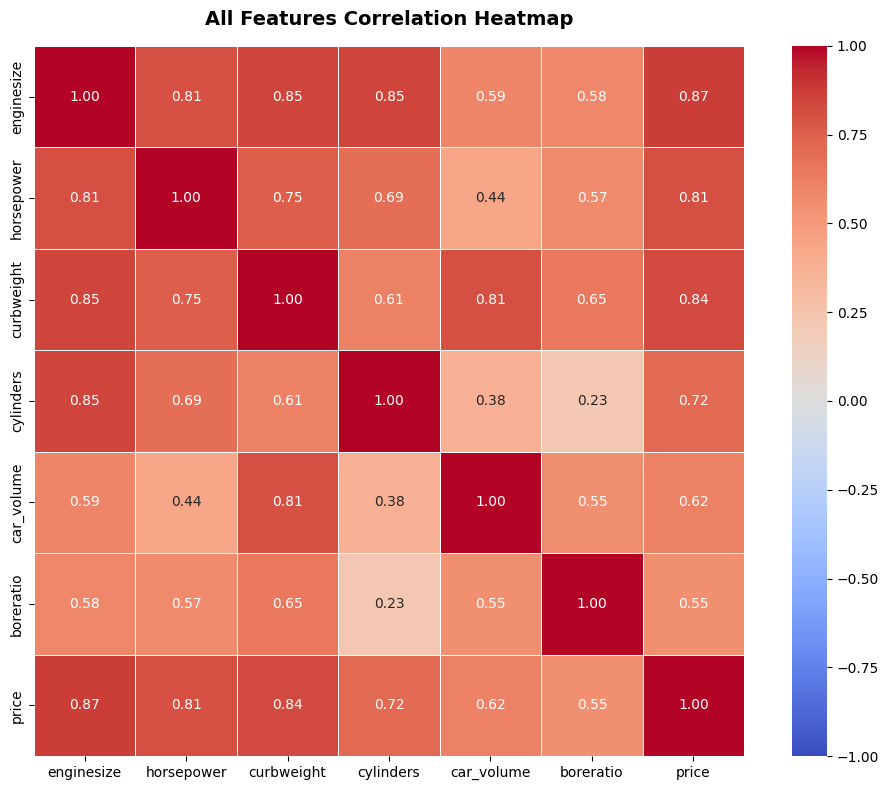

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our finalized list of clean numerical features + target
final_features = [
    'enginesize', 
    'horsepower', 
    'curbweight', 
    'cylinders', 
    'car_volume', 
    'boreratio',
    'price'
]

# 2. Compute the Pearson correlation matrix for our clean subset
corr_matrix = df[final_features].corr()

# 3. Set up the figure canvas
plt.figure(figsize=(10, 8))

# 4. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show exact numerical scores inside each cell
    fmt='.2f',           # Round scores to 2 decimal places
    cmap='coolwarm',     # Red = Strong Positive, Blue = Strong Negative
    vmin=-1, vmax=1,     # Fix color scale limits between -1.0 and +1.0
    linewidths=0.5,      # Add subtle line dividers between cells
    square=True          # Keep cells as perfect squares
)

plt.title('All Features Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

The curbweight and enginesize, and overall dimensions (carlength, carwidth, wheelbase) often move together. In statistics, when features are strongly correlated with each other, we call it Multicollinearity.
To make better use of the heat map to read off features that are good Correlation Scores to price we need to ignore obviously related things.

Multicollinearity: When two or more features measure almost the same underlying physical property (like length, width, and weight), including all of them in a model distorts their true individual effect on price.

To fix this, we can design a weighted scoring system that rewards a feature for having a high correlation with the target (price) while penalising it for being redundant (too similar to other features already selected).

Performance Signal (enginesize & horsepower) The Argument: Both enginesize ($r = 0.87$) and horsepower ($r = 0.81$) carry the strongest direct relationships with price across the entire dataset.  But what if we exclude the extreme ends of car makes?  We do this because by filtering out extreme budget and extreme luxury rows, the spread of remaining data points compresses. This prevents skewness—where extreme values drag the correlation score artificially up or down.

The redraw heatmap removes those budget and rare luxuary rows leaving a more reasonable set of features with relationship to price.

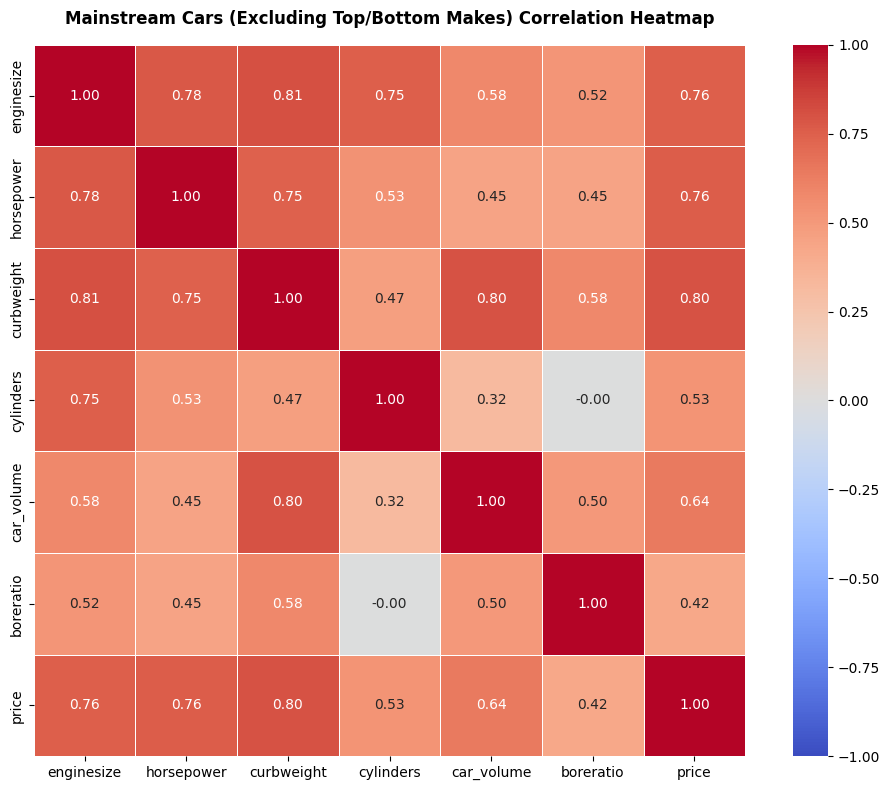

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Define list of clean numerical features AND target
features_with_target = [
    'enginesize', 
    'horsepower', 
    'curbweight', 
    'cylinders', 
    'car_volume', 
    'boreratio',
    'price'
]

# 2. Exclude top 3 and bottom 3 makes
excluded_makes = ['jaguar', 'buick', 'porsche', 'chevrolet', 'dodge', 'plymouth']
df_filtered = df[~df['make'].isin(excluded_makes)]
##~df['make'] - gemini code suggested to use for removing Specific Items from the Dataset.  We remove the high and low car makes to get farer corrolations.
# 3. Compute Pearson correlation matrix on filtered data
corr_matrix = df_filtered[features_with_target].corr()

# 4. Create a mask to hide the self-correlation diagonal (1.00 values)
#mask = np.eye(len(corr_matrix), dtype=bool)

# 5. Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
               # Hides the redundant 1.00 diagonal line
    annot=True,          # Show exact numerical scores inside each cell
    fmt='.2f',           # Round scores to 2 decimal places
    cmap='coolwarm',     # Red = Strong Positive, Blue = Strong Negative
    vmin=-1, vmax=1,     # Fix color scale limits
    linewidths=0.5,      # Line dividers
    square=True          # Square cells
)

plt.title('Mainstream Cars (Excluding Top/Bottom Makes) Correlation Heatmap', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
#Saved heatmap as figure.
#plt.savefig('my_chart.png', dpi=300, bbox_inches='tight')

plt.show()

## Conclusion from heatmap

Filtering out budget and ultra-luxury outliers removed statistical noise and highlighted the true mechanical factors behind car prices. Engine size ($r = 0.76$) and horsepower ($r = 0.76$) show the strongest direct relationship with price, accurately capturing engine capacity and performance. Car volume ($r = 0.64$) provides a distinct second factor representing physical size. Curb weight was excluded because its relationship to price is already covered by engine size and total volume mass, avoiding redundant data in our model.

## Interactive presentation chart of findings.

We have isolated three primary features that drive vehicle pricing: Engine Size, Horsepower, and Car Volume. To demonstrate their combined impact, we rendered an interactive 3D Plotly visualization displaying all three dimensions across the dataset simultaneously. The chart includes interactive toggles to segment the data by binary features: fuel type, turbo aspiration, door count, and engine location.

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px




# Reconstruct readable string categories from binary 1/0 flags
df['fueltype'] = np.where(df['fueltype_gas'] == 1, 'Gas', 'Diesel')
df['aspiration'] = np.where(df['aspiration_turbo'] == 1, 'Turbo', 'Standard')
df['doors'] = np.where(df['doornumber_four'] == 1, '4 Doors', '2 Doors')
df['engine_location'] = np.where(df['enginelocation_front'] == 1, 'Front Engine', 'Rear Engine')

# 1. Reconstruct readable string categories
df['fueltype'] = np.where(df['fueltype_gas'] == 1, 'Gas', 'Diesel')
df['aspiration'] = np.where(df['aspiration_turbo'] == 1, 'Turbo', 'Standard')
df['doors'] = np.where(df['doornumber_four'] == 1, '4 Doors', '2 Doors')
df['engine_location'] = np.where(df['enginelocation_front'] == 1, 'Front Engine', 'Rear Engine')

# 2. Build the interactive 3D scatter chart
fig = px.scatter_3d(
    df,
    x='horsepower',
    y='enginesize',
    z='car_volume',
    color='price',
    symbol='fueltype', # Distinguishes Gas vs Diesel by marker shape
    hover_data={
        'aspiration': True,
        'doors': True,
        'engine_location': True,
        'price': ':$' # Format price as currency
    },
    color_continuous_scale='Viridis',
    title="3D Analysis: Vehicle Price vs. Horsepower, Engine Size, & Volume"
)

# 3. Fine-tune layout and axis titles
fig.update_layout(
    scene=dict(
        xaxis_title='Horsepower (hp)',
        yaxis_title='Engine Size',
        zaxis_title='Car Volume (m³)'
    ),
    legend_title_text='Fuel Type (Click to Toggle)',
    margin=dict(l=0, r=0, b=0, t=50)
)

# Spread legend items horizontally across the top of the chart
fig.update_layout(
    legend=dict(
        orientation="h",        # Layout items side-by-side horizontally
        yanchor="bottom",       # Align from the bottom of the legend box
        y=0.85,                 # Place slightly above the plot (above Y=1.0)
        xanchor="center",       # Center-align the legend
        x=0.5,                  # Position at the horizontal midpoint (X=0.5)
        font=dict(size=12)
    )
)
# 4. Render or save figure
fig.show()